# Parameter estimation
In this notebook, we estimate kinetic parameters of a small model based on experimental time-course data. 

We use [BIOMD0000000010](https://www.ebi.ac.uk/biomodels/BIOMD0000000010) (Kholodenko, 2000), a model of the **MAPK (mitogen-activated protein kinase) signalling cascade**. MAPK cascades are three-tiered phosphorylation relays (MAPKKK → MAPKK → MAPK) found in essentially all eukaryotic cells, where they transmit signals from surface receptors to the nucleus and control processes such as cell proliferation, differentiation and the cell cycle. Because each tier can act as an ultrasensitive (switch-like) amplifier, a negative feedback loop from the output (MAPK) back onto the input (MAPKKK) can turn the cascade into a biochemical oscillator — the phenomenon this model was built to explain.

In the model, the three tiers correspond to the species pairs `Mos`/`Mos-P` (MAPKKK), `Mek1`/`Mek1-P`/`Mek1-PP` (MAPKK) and `Erk2`/`Erk2-P`/`Erk2-PP` (MAPK).

**The data.** `mapk_data.csv` contains a time course of two phosphorylated species, `Mos-P` (MAPKKK-P) and `Erk2-P` (MAPK-P).

**The task.** The model predictions do not reproduce this data. We will use COPASI's parameter estimation task, accessed through the `basico` Python interface, to fit selected kinetic parameters so that the model reproduces the measured time course.

This exercise was adapted from https://jpahle.github.io/DynamiCoRC/parameterestimation

In [1]:
import sys
if '../..' not in sys.path:
    sys.path.append('../..')

from basico import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### Load model and data

In [2]:
model = load_model('models/BIOMD0000000010_unoptimized.xml')
exp_data = pd.read_csv('models/mapk_data.csv')

# we rename the data for easier mapping to model values
exp_data.rename(columns = {'Mos-P':'[Mos-P]', 'Erk2-P':'[Erk2-P]'},
                inplace=True)
exp_data.head()

,Time,[Mos-P],[Erk2-P]
0,50,65.7,13.20
1,100,98.3,20.50
2,150,91.9,43.10
3,200,88.5,66.40
4,300,80.4,2.03


A quick look at the model itself is useful before fitting anything: what species does it contain, and what are their starting concentrations?

In [3]:
get_species()[['initial_concentration']]

,initial_concentration
name,
Mos,90.0
Mos-P,10.0
Mek1,280.0
Mek1-P,10.0
Mek1-PP,10.0
Erk2,280.0
Erk2-P,10.0
Erk2-PP,10.0


### Tell COPASI how the data maps onto the model


In [4]:
add_experiment('exp1', exp_data)
get_experiment_mapping('exp1')

,type,mapping,cn,column_name
column,,,,
0,time,,,Time
1,dependent,[Mos-P],"CN=Root,Model=Kholodenko2000 - Ultrasensitivit...",[Mos-P]
2,dependent,[Erk2-P],"CN=Root,Model=Kholodenko2000 - Ultrasensitivit...",[Erk2-P]


### A helper function to compare simulation and experiment

It plots both observables side by side, and also reports the **root-mean-square error (RMSE)** between simulation and data, interpolating the simulated trajectory onto the experimental time points.

In [5]:
def compute_rmse(sim_data, exp_data, sim_col, exp_col):
    # RMSE between a simulated trajectory and experimental observations,
    # interpolating the simulation onto the experimental time points.
    sim_at_exp_times = np.interp(exp_data['Time'], sim_data.index, sim_data[sim_col])
    residuals = sim_at_exp_times - exp_data[exp_col]
    return np.sqrt(np.mean(residuals**2))


def plot_predicted_experimental(sim_data, exp_data, title):

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for ax, sim_col, exp_col, label in zip(
        axes, ['Mos-P', 'Erk2-P'], ['[Mos-P]', '[Erk2-P]'], ['Mos-P', 'Erk2-P']
    ):
        rmse = compute_rmse(sim_data, exp_data, sim_col, exp_col)
        ax.plot(sim_data.index, sim_data[sim_col], label='Prediction')
        ax.scatter(exp_data['Time'], exp_data[exp_col], color='C1', label='Experiment')
        ax.set_xlabel('Time')
        ax.set_ylabel('Concentration')
        ax.set_title(f'{label}  (RMSE = {rmse:.2f})')

    fig.suptitle(title, y=1.08)
    fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center',
               bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
    fig.tight_layout()
    plt.show()


### Simulate the unoptimized parameters

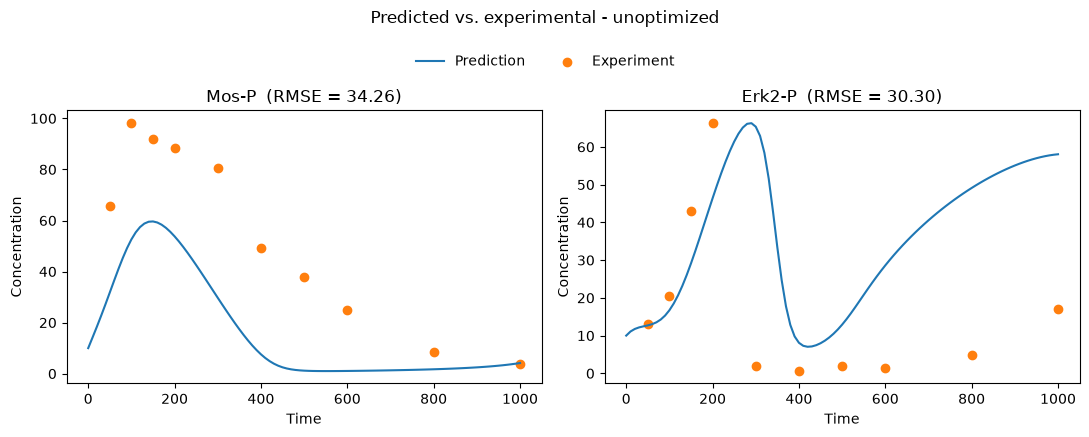

In [6]:
SIM_DURATION = exp_data['Time'].max()

sim_data = run_time_course(duration=SIM_DURATION)
plot_predicted_experimental(sim_data, exp_data,
                            'Predicted vs. experimental - unoptimized');

The model predictions clearly do not match the experimental data - both the shape and the timing of the response are off, and the RMSE is quite high. We will now search for parameter values that make the model's behaviour consistent with what we measured.

Let's see what parameters are currently in the model. Each row is a local parameter of one reaction (e.g. a Michaelis constant `KK` or a maximal rate `V`), named `(reaction name).parameter name`. The `value` column shows the current value used in the simulation above.

In [7]:
get_reaction_parameters()

,value,reaction,type,mapped_to
name,,,,
(MAPKKK activation).K1,10.000,MAPKKK activation,local,
(MAPKKK activation).Ki,9.000,MAPKKK activation,local,
(MAPKKK activation).V1,1.500,MAPKKK activation,local,
(MAPKKK activation).n,1.000,MAPKKK activation,local,
(MAPKKK inactivation).KK2,8.000,MAPKKK inactivation,local,
(MAPKKK inactivation).V2,0.400,MAPKKK inactivation,local,
(phosphorylation of MAPKK).KK3,15.000,phosphorylation of MAPKK,local,
(phosphorylation of MAPKK).k3,0.025,phosphorylation of MAPKK,local,
(phosphorylation of MAPKK-P).KK4,15.000,phosphorylation of MAPKK-P,local,


### Fitting a single parameter

First, we will optimize just one parameter: the maximal rate of the MAPKKK activation reaction `(MAPKKK activation).V1`, the first step of the cascade.

We need to give COPASI a search range (`lower`/`upper`) for this parameter. Here we set a very wide range, spanning 12 orders of magnitude, because we have no prior information about a realistic value. If you do have prior knowledge - for example published rate constants for a related enzyme, or measurements from a similar system - use it. Narrower, biologically-motivated bounds make the optimisation faster and more reliable, and reduce the risk of finding a value that fits the data but has no physical meaning.

In [8]:
fit_items = [
            {'name': '(MAPKKK activation).V1', 'lower': 1e-6, 'upper': 1e6}
        ]
set_fit_parameters(fit_items)


COPASI offers many optimisation algorithms. Broadly, there are **global** methods (which search the whole space and are less likely to get stuck, but need many model evaluations) and **local** methods (fast, but need a good starting guess and can get stuck in the wrong place).

We use **Evolution Strategy (SRES)**, a global method recommended in the COPASI documentation as a good default. Other methods may work better or faster for a given model and dataset - it's worth trying more than one, especially for a result you plan to publish.

One thing to keep in mind: SRES uses random numbers internally, so running this same cell twice will usually give slightly different fitted values and objective function scores. For a single, well-constrained parameter like this one, the difference should be small. For the harder case in the next section, it can be much larger, and that itself is informative.

In [9]:
fitting1 = run_parameter_estimation(method='Evolution Strategy (SRES)',
                                   update_model=True)
fitting1

,lower,upper,sol,affected
name,,,,
(MAPKKK activation).V1,1e-06,1000000.0,3.425987,[]


`fitting1` shows the fitted value (`sol`) found within the given bounds. Since `update_model=True`, the model's parameter has already been updated to this value, so we can simulate with it directly.

`get_fit_statistic()` reports the **objective function value** (`obj`, the sum of squared residuals COPASI minimised) and the **root-mean-square of the residuals** (`rms`) across all data points. This gives us a single number to compare fit quality against as we make the model more complex below.

In [10]:
get_fit_statistic()

{'obj': 1773.307156839278,
 'rms': 9.416228429788855,
 'sd': 9.660846527252149,
 'f_evals': 23905,
 'failed_evals_exception': 0,
 'failed_evals_nan': 0,
 'constraint_evals': 0,
 'failed_constraint_evals': 0,
 'cpu_time': 8.557193999999999,
 'data_points': 20,
 'valid_data_points': 20,
 'evals_per_sec': 0.0003579667015268772}

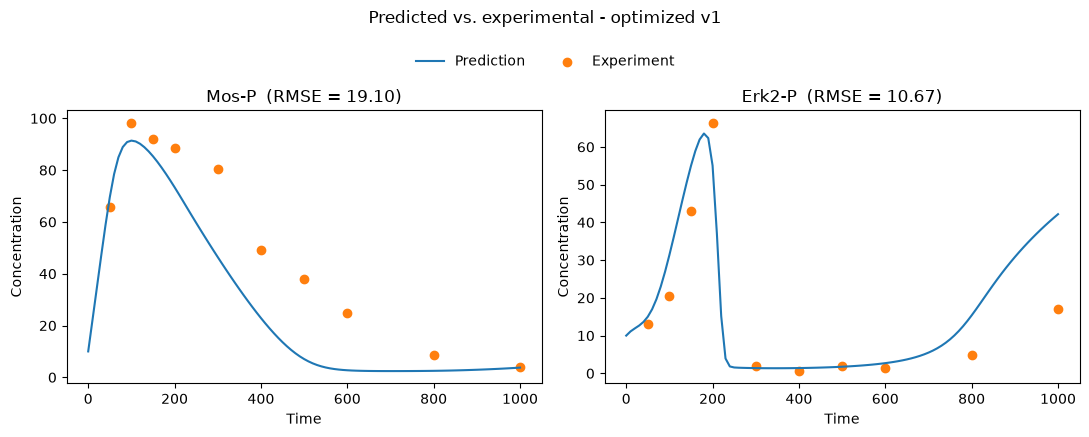

In [11]:
sim_data2 = run_time_course(duration=SIM_DURATION)
plot_predicted_experimental(sim_data2, exp_data,
                            "Predicted vs. experimental - optimized v1")

### Fitting several parameters at once

Now let's fit six parameters, spanning both the MAPKKK step and the downstream dephosphorylation steps.

**A word of caution first.** Every extra free parameter gives the optimiser more freedom to fit the data, including its noise. This can produce a good-looking fit that doesn't actually reflect the true kinetics. We only have 2 measured species at 10 time points each - 20 data points in total - and very wide, uninformative bounds. Fitting six parameters at once, in this setting, means some of them may not be well constrained by the data: very different combinations of values could fit almost equally well. Watch the fitted values below — if one lands right at (or very close to) its lower or upper bound, that's a sign the data doesn't constrain that parameter, not a sign of a good fit.

(Note: because `update_model=True` was used above, this fit starts from the model that already has the optimized `V1` from the previous section, not from the original unoptimized parameters. Each fit here builds on the previous one, rather than starting fresh.)

In [12]:
fit_items = [
    {'name': '(MAPKKK activation).V1', 'lower': 1e-6, 'upper': 1e6},
    {'name': '(MAPKKK inactivation).V2', 'lower': 1e-6, 'upper': 1e6},
    {'name': '(dephosphorylation of MAPKK-PP).V5', 'lower': 1e-6, 'upper': 1e6},
    {'name': '(dephosphorylation of MAPKK-P).V6', 'lower': 1e-6, 'upper': 1e6},
    {'name': '(dephosphorylation of MAPK-PP).V9', 'lower': 1e-6, 'upper': 1e6},
    {'name': '(dephosphorylation of MAPK-P).V10', 'lower': 1e-6, 'upper': 1e6},
]
set_fit_parameters(fit_items)

fitting2 = run_parameter_estimation(method='Evolution Strategy (SRES)',
                         update_model=True)
fitting2

,lower,upper,sol,affected
name,,,,
(MAPKKK activation).V1,1e-06,1000000.0,2.546392,[]
(MAPKKK inactivation).V2,1e-06,1000000.0,0.255365,[]
(dephosphorylation of MAPKK-PP).V5,1e-06,1000000.0,0.515942,[]
(dephosphorylation of MAPKK-P).V6,1e-06,1000000.0,2.493785,[]
(dephosphorylation of MAPK-PP).V9,1e-06,1000000.0,0.773103,[]
(dephosphorylation of MAPK-P).V10,1e-06,1000000.0,0.711895,[]


In [13]:
get_fit_statistic()

{'obj': 31.602360988406424,
 'rms': 1.2570274656586948,
 'sd': 1.502435189674379,
 'f_evals': 23910,
 'failed_evals_exception': 0,
 'failed_evals_nan': 0,
 'constraint_evals': 0,
 'failed_constraint_evals': 0,
 'cpu_time': 9.635648999999999,
 'data_points': 20,
 'valid_data_points': 20,
 'evals_per_sec': 0.0004029966122961104}

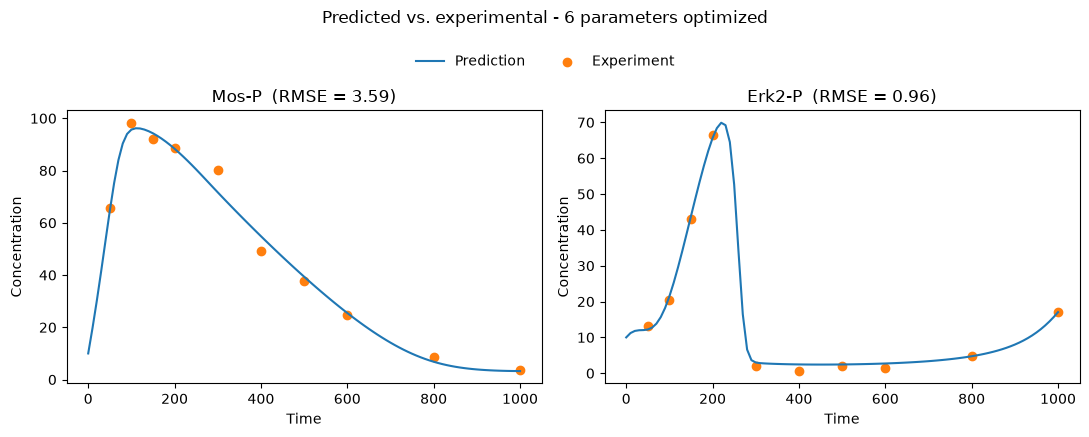

In [14]:
sim_data3 = run_time_course(duration=SIM_DURATION)

plot_predicted_experimental(sim_data3, exp_data,
                            "Predicted vs. experimental - 6 parameters optimized")

### Summary

It's up to you, as the modeller, which parameters to fit and how many. If some parameters are already known from independent experiments, fix them and only fit the unknown ones. In general: the more data you have, and the tighter and more realistic the bounds you can justify, the more trustworthy your estimates will be. A fit to sparse data with wide bounds should be treated as a starting point, not a final answer.